# Static vs dynamic response and distance magnitudes

This notebook compares static and dynamic responses at one chosen timepoint per condition, at three levels:

1. **Pairwise distances**: all entries of the RDM (`cfg.rdm_metric`) across matched stimuli;
2. **Population average response**: each stimulus's response averaged across channels;
3. **Single channels**: each channel's response across stimuli.

Every comparison shows mean ± SD for all items, the top `cfg.top_percent`% and the bottom `cfg.bottom_percent`%. The tails are taken from each condition's own ranking, so the static and dynamic top bars can contain different pairs or images. Each panel reports Welch's t-test.

In [29]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.stats import pearsonr, spearmanr


# Locate the repository whether the notebook starts in the project root or scripts/.
working_directory = Path.cwd().resolve()
project_candidates = (working_directory, *working_directory.parents)
PROJECT_ROOT = next(
    candidate for candidate in project_candidates
    if (candidate / "config.yaml").is_file()
)
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
for source_path in (paths["src_path"], paths["useful_stuff_path"]):
    if source_path not in sys.path:
        sys.path.append(source_path)
    # end if source_path
# end for source_path
from useful_stuff.general_utils.utils import TimeSeries, create_RDM
from project_specific_utils import (
    compare_static_dynamic_tails,
    compute_rdm_timeseries,
    cross_temporal_tail_ttest,
    load_natraster,
    match_timed_static_movie_rasters,
    plot_static_dynamic_bars,
    plot_static_dynamic_drsa_peak,
    plot_static_dynamic_matrix,
    rdm_tail_timecourses,
    select_tail_indices,
    static_dynamic_drsa_peak,
    window_mean_responses,
)

## Configuration

`static_time_ms` and `dynamic_time_ms` are the single timebins compared, measured from stimulus onset after resampling to `new_fs`. `top_percent` and `bottom_percent` set the tails used in every analysis. `channel_alpha` is the family-wise threshold for the single-channel tests; it is Bonferroni-corrected across channels. `good_channels` uses one-based MATLAB channel numbers with both endpoints included.

Set `timepoint_source="drsa_peak"` to ignore `static_time_ms`/`dynamic_time_ms` and instead compare the two timebins at which the conditions match best: the maximum of the static-dynamic dRSA (dynamic time × static time correlation of `rdm_metric` RDMs, computed at `new_fs`) inside `drsa_static_search_ms` × `drsa_dynamic_search_ms`.


In [ ]:
@dataclass
class Cfg:
    dynamic_exp_name: str = "paul_20260831to0919" #'red_20260720to0921' # "baby1_260716to24" #  
    static_exp_name: str = "paul_20260901to0923" #'red_20260726to0923' # "baby1_260718to27"# 
    # Options: "last_frame", "2000ms", or "2250ms".
    static_response: str = "last_frame"
    good_channels: tuple[int, int] | None = (1, 64) # (84,186) #
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None
    # Stimulus identities (name without img_/vid_ prefix) dropped after matching.
    # IMG_46581 has 631 movie repetitions vs 3-116 for every other movie.
    excluded_stimuli: tuple[str, ...] = ()

    source_fs: float = 1000
    new_fs: float = 100
    rdm_metric: str = "euclidean"
    # Single timebins compared between conditions.
    static_time_ms: float = 100
    dynamic_time_ms: float = 2500
    # "fixed" uses the times above; "drsa_peak" uses the best-matching
    # static/dynamic timebins of the static-dynamic dRSA.
    timepoint_source: str = "drsa_peak" # "fixed"
    drsa_rsa_metric: str = "correlation"
    drsa_static_search_ms: tuple[float, float] = (0, 500)
    drsa_dynamic_search_ms: tuple[float, float] = (2400, 3500)
    # Gaussian sigma (dRSA bins) used only to locate a robust peak; 0 = raw.
    drsa_smoothing_sigma_bins: float = 1
    # Static response to the previous movie frame ("2250ms", "2000ms") whose
    # RDM is regressed out of the static RDM before the dRSA; None = off.
    drsa_previous_static_response: str | None = "2250ms"
    # "signal": regress the previous-frame response out of each channel's
    # static response, then build the RDM from the residuals;
    # "rdm": regress the previous-frame RDM out of the static RDM.
    drsa_previous_regression: str = "signal"
    # Tails taken from each condition's own ranking.
    top_percent: float = 5
    bottom_percent: float = 5
    # Family-wise alpha for the single-channel tests (Bonferroni).
    channel_alpha: float = 0.05
    # Section 4: half-open windows (ms from onset) averaged before the RDMs.
    static_average_window_ms: tuple[float, float] = (80, 150)
    dynamic_average_window_ms: tuple[float, float] = (2480, 2550)
    # OC_presentation-style static-dynamic matrix plots.
    matrix_figsize: tuple[float, float] = (10, 4)
    drsa_matrix_cmap: str = "viridis"
    drsa_matrix_vmin: float | None = 0
    drsa_matrix_vmax: float | None = 0.65
    last_frame_onset_ms: float = 2500
    ticks_size: float = 20
    label_size: float = 25
    figure_dpi: int = 120
# EOC


cfg = Cfg()
if cfg.static_response not in {"last_frame", "2000ms", "2250ms"}:
    raise ValueError(
        "static_response must be 'last_frame', '2000ms', or '2250ms'."
    )
# end if invalid static_response
if cfg.timepoint_source not in ("fixed", "drsa_peak"):
    raise ValueError("timepoint_source must be 'fixed' or 'drsa_peak'.")
# end if invalid timepoint_source
if cfg.drsa_previous_regression not in ("signal", "rdm"):
    raise ValueError("drsa_previous_regression must be 'signal' or 'rdm'.")
# end if invalid drsa_previous_regression
frame_order_ms = {"2000ms": 2000, "2250ms": 2250, "last_frame": 2500}
if cfg.drsa_previous_static_response is not None and (
        frame_order_ms.get(cfg.drsa_previous_static_response, np.inf)
        >= frame_order_ms[cfg.static_response]
        ):
    raise ValueError(
        "drsa_previous_static_response must be a frame shown before "
        "static_response ('2000ms' or '2250ms')."
    )
# end if invalid previous frame
plt.rcParams["figure.dpi"] = cfg.figure_dpi
cfg

Cfg(dynamic_exp_name='paul_20260831to0919', static_exp_name='paul_20260901to0923', static_response='last_frame', good_channels=(1, 64), use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, source_fs=1000, new_fs=100, rdm_metric='euclidean', static_time_ms=100, dynamic_time_ms=2500, timepoint_source='drsa_peak', drsa_rsa_metric='correlation', drsa_static_search_ms=(0, 500), drsa_dynamic_search_ms=(2400, 3500), drsa_smoothing_sigma_bins=1, drsa_previous_static_response='2250ms', top_percent=5, bottom_percent=5, channel_alpha=0.05, static_average_window_ms=(80, 150), dynamic_average_window_ms=(2480, 2550), matrix_figsize=(10, 4), drsa_matrix_cmap='viridis', drsa_matrix_vmin=0, drsa_matrix_vmax=0.65, last_frame_onset_ms=2500, ticks_size=20, label_size=25, figure_dpi=120)

## Load and align the natraster responses

Identical to `rsa_distances_matching.ipynb`: the same physical channels are kept in both sessions, and static and movie conditions are matched by stimulus identity.

In [41]:
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_natraster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat"

# By default, use the reliability list estimated from the static session.
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / "reliable_channels.yaml"
    )
    reliable_channels_key = (
        cfg.reliable_channels_key or cfg.static_exp_name
    )
# end if cfg.use_reliable_channels

# Apply the identical physical-channel selection to both sessions.
loaded_static, static_names, static_channel_numbers = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_dynamic, dynamic_names, dynamic_channel_numbers = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(static_channel_numbers, dynamic_channel_numbers):
    raise ValueError(
        "Static and dynamic sessions retained different physical channels."
    )
# end if retained channels differ
channel_numbers = static_channel_numbers

(
    last_frame_rasters,
    dynamic_rasters,
    image_2000ms_rasters,
    image_2250ms_rasters,
    shared_stimuli,
    aligned_names,
) = match_timed_static_movie_rasters(
    loaded_static, static_names, loaded_dynamic, dynamic_names,
)

# Drop excluded identities from every aligned condition, keeping the order.
missing_exclusions = set(cfg.excluded_stimuli) - set(shared_stimuli)
if missing_exclusions:
    raise ValueError(f"Excluded stimuli are not matched: {sorted(missing_exclusions)}")
# end if missing_exclusions
keep = np.array([identity not in cfg.excluded_stimuli for identity in shared_stimuli])
last_frame_rasters = last_frame_rasters[:, :, keep]
dynamic_rasters = dynamic_rasters[:, :, keep]
image_2000ms_rasters = image_2000ms_rasters[:, :, keep]
image_2250ms_rasters = image_2250ms_rasters[:, :, keep]
shared_stimuli = [identity for identity, kept in zip(shared_stimuli, keep) if kept]
aligned_names = {
    condition: [name for name, kept in zip(names, keep) if kept]
    for condition, names in aligned_names.items()
}

static_rasters_by_response = {
    "last_frame": last_frame_rasters,
    "2000ms": image_2000ms_rasters,
    "2250ms": image_2250ms_rasters,
}
static_names_by_response = {
    "last_frame": aligned_names["image"],
    "2000ms": aligned_names["image_2000ms"],
    "2250ms": aligned_names["image_2250ms"],
}
static_rasters = static_rasters_by_response[cfg.static_response]
selected_static_names = static_names_by_response[cfg.static_response]

if static_rasters.shape[0] != dynamic_rasters.shape[0]:
    raise ValueError(
        "Static and dynamic sessions must contain the same physical channels."
    )
# end if channel counts differ

print(f"Static natraster:  {static_path}")
print(f"Dynamic natraster: {dynamic_path}")
print(f"Reliable-channel filter: {cfg.use_reliable_channels}")
if cfg.use_reliable_channels:
    print(f"Reliability config: {reliable_channels_config}")
    print(f"Reliability key: {reliable_channels_key}")
# end if cfg.use_reliable_channels
print(f"Selected static response: {cfg.static_response}")
print(
    "First aligned pair:", selected_static_names[0],
    "<->", aligned_names["movie"][0],
)
print(f"Excluded stimuli: {list(cfg.excluded_stimuli)}")
print(f"Matched stimuli: {len(shared_stimuli)}")
print(f"Selected MATLAB channels: {channel_numbers.tolist()}")
print(f"Selected channel count: {len(channel_numbers)}")
print("Static shape: ", static_rasters.shape, "(channels, time, stimuli)")
print("Dynamic shape:", dynamic_rasters.shape, "(channels, time, stimuli)")

Static natraster:  /Users/tizianocausin/sd_local/data/paul_20260901to0923_natraster_img.mat
Dynamic natraster: /Users/tizianocausin/sd_local/data/paul_20260831to0919_natraster_vid.mat
Reliable-channel filter: True
Reliability config: /Users/tizianocausin/Desktop/static_dynamic/reliable_channels.yaml
Reliability key: paul_20260901to0923
Selected static response: last_frame
First aligned pair: img_0_0_41171.jpg <-> vid_0_0_41171.mp4
Matched stimuli: 100
Selected MATLAB channels: [1, 4, 7, 9, 10, 12, 15, 16, 18, 19, 21, 23, 24, 25, 26, 27, 29, 32, 37, 41, 48]
Selected channel count: 21
Static shape:  (21, 1000, 100) (channels, time, stimuli)
Dynamic shape: (21, 3500, 100) (channels, time, stimuli)


## Responses at the selected timepoints

Both rasters are resampled to `cfg.new_fs`. The static and dynamic response matrices are channels × stimuli at the selected timebins, with stimuli in the same matched order. With `timepoint_source="drsa_peak"`, the two timebins come from the maximum of the static-dynamic dRSA instead of the configured times.

The previous-frame regression (`drsa_previous_static_response`) affects only the dRSA used to find the peak. With `drsa_previous_regression="signal"`, each channel's static response is regressed across stimuli on the same channel's response to the previous frame, independently at every static bin, and the static RDM is built from the residual responses. With `"rdm"`, the static RDM itself is regressed on the previous-frame RDM across stimulus pairs. The magnitude analyses below always use the raw responses.

dRSA peak 0.192 at static 345 ms, dynamic 2915 ms (bin centres)
Static last_frame RDM residualized on the 2250ms RDM; variance explained at the static peak: 6.9%


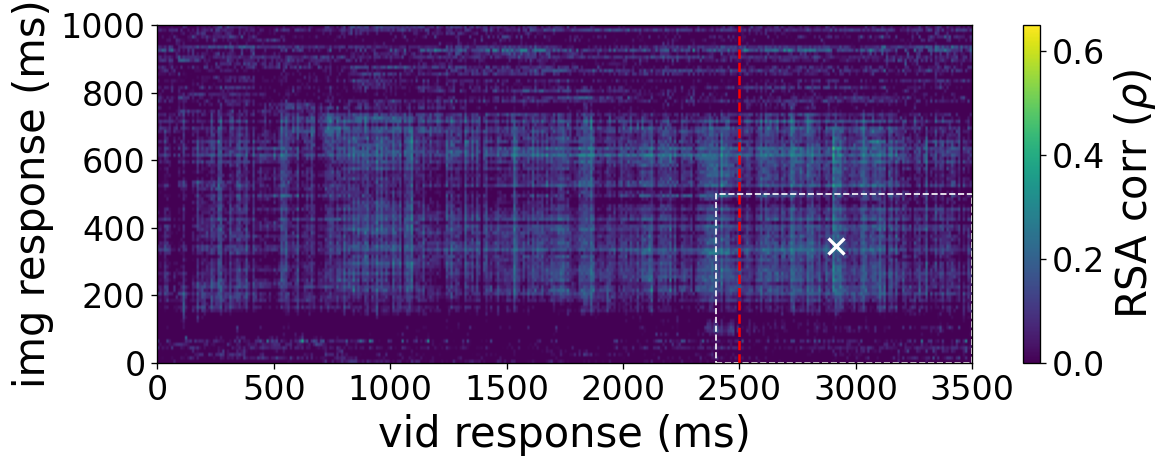

Static responses:  (21, 100) (channels, stimuli)
Dynamic responses: (21, 100) (channels, stimuli)


In [42]:
static = TimeSeries(static_rasters, cfg.source_fs)
static.resample(cfg.new_fs)
dynamic = TimeSeries(dynamic_rasters, cfg.source_fs)
dynamic.resample(cfg.new_fs)

if cfg.timepoint_source == "drsa_peak":
    # Neural response to the previous frame shown as a static image,
    # resampled like the selected static response.
    previous_static_array = None
    if cfg.drsa_previous_static_response is not None:
        previous_static = TimeSeries(
            static_rasters_by_response[cfg.drsa_previous_static_response],
            cfg.source_fs,
        )
        previous_static.resample(cfg.new_fs)
        previous_static_array = previous_static.array
    # end if previous frame requested
    # Responses are already at new_fs, so every sample is one dRSA bin.
    drsa_peak = static_dynamic_drsa_peak(
        static.array, dynamic.array,
        source_fs=cfg.new_fs,
        drsa_fs=cfg.new_fs,
        static_search_ms=cfg.drsa_static_search_ms,
        dynamic_search_ms=cfg.drsa_dynamic_search_ms,
        half_window_ms=0,
        rdm_metric=cfg.rdm_metric,
        rsa_metric=cfg.drsa_rsa_metric,
        smoothing_sigma_bins=cfg.drsa_smoothing_sigma_bins,
        previous_static_rasters=previous_static_array,
        previous_regression=cfg.drsa_previous_regression,
    )
    static_index = drsa_peak["peak_static_index"]
    dynamic_index = drsa_peak["peak_dynamic_index"]

    figure, axis = plt.subplots(figsize=cfg.matrix_figsize)
    plot_static_dynamic_drsa_peak(
        axis, drsa_peak, cfg.drsa_static_search_ms, cfg.drsa_dynamic_search_ms,
        cmap=cfg.drsa_matrix_cmap,
        vmin=cfg.drsa_matrix_vmin,
        vmax=cfg.drsa_matrix_vmax,
        last_frame_onset_ms=cfg.last_frame_onset_ms,
        ticks_size=cfg.ticks_size,
        label_size=cfg.label_size,
    )
    figure.tight_layout()
    print(
        f"dRSA peak {drsa_peak['peak_value']:.3f} at static "
        f"{drsa_peak['peak_static_ms']:g} ms, dynamic "
        f"{drsa_peak['peak_dynamic_ms']:g} ms (bin centres)"
    )
    if cfg.drsa_previous_static_response is not None:
        variance_removed = drsa_peak["previous_frame_variance_removed"]
        regressed_quantity = (
            "channel responses" if cfg.drsa_previous_regression == "signal"
            else "RDM"
        )
        print(
            f"Static {cfg.static_response} {regressed_quantity} residualized on "
            f"the {cfg.drsa_previous_static_response} {regressed_quantity}; "
            f"variance explained at the static peak: "
            f"{100 * variance_removed[drsa_peak['peak_static_index']]:.1f}%"
        )
    # end if previous frame regressed out
    plt.show()
else:
    # Convert the configured times to indices in the resampled responses.
    static_index = int(round(cfg.static_time_ms * cfg.new_fs / 1000))
    dynamic_index = int(round(cfg.dynamic_time_ms * cfg.new_fs / 1000))
# end if drsa_peak
# Timebin onsets, matching the index convention used above.
static_time_ms = static_index * 1000 / cfg.new_fs
dynamic_time_ms = dynamic_index * 1000 / cfg.new_fs
if not 0 <= static_index < static.array.shape[1]:
    raise ValueError("static_time_ms is outside the static response.")
# end if static index is invalid
if not 0 <= dynamic_index < dynamic.array.shape[1]:
    raise ValueError("dynamic_time_ms is outside the dynamic response.")
# end if dynamic index is invalid

# Channels x stimuli at one timebin per condition.
static_responses = static.array[:, static_index, :]
dynamic_responses = dynamic.array[:, dynamic_index, :]
condition_labels = (
    f"static {static_time_ms:g} ms", f"dynamic {dynamic_time_ms:g} ms",
)
print("Static responses: ", static_responses.shape, "(channels, stimuli)")
print("Dynamic responses:", dynamic_responses.shape, "(channels, stimuli)")

## 1. Pairwise distances

One RDM per condition at the selected timebin. Pairwise distances are not independent (every stimulus contributes to many pairs), so these p-values are optimistic.

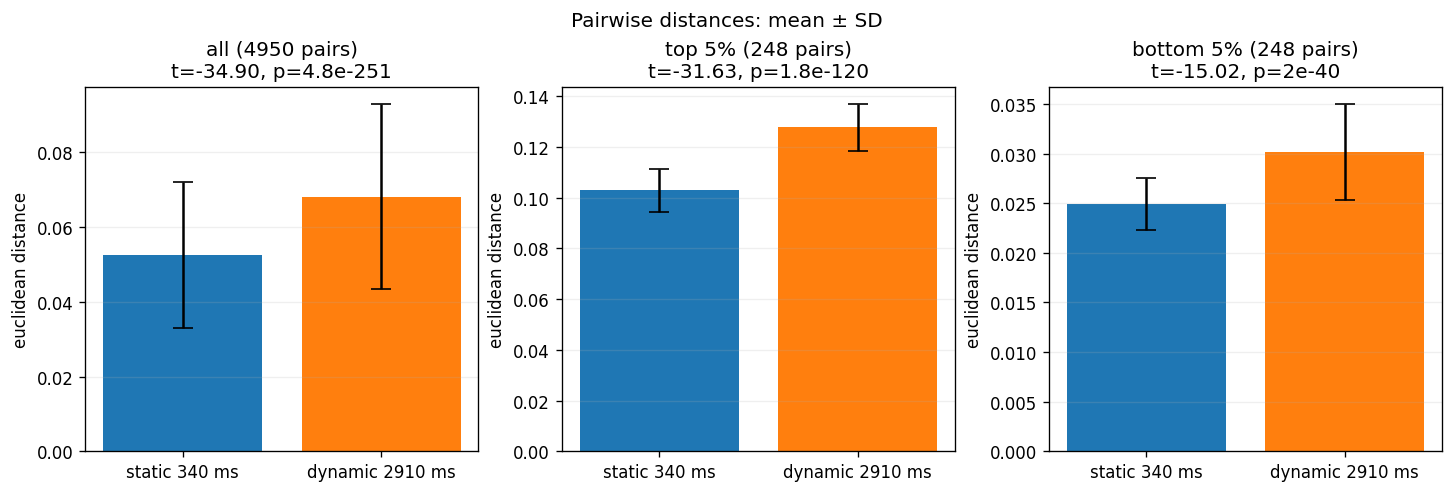

In [43]:
static_rdm = create_RDM(static_responses, cfg.rdm_metric)
dynamic_rdm = create_RDM(dynamic_responses, cfg.rdm_metric)
distance_comparison = compare_static_dynamic_tails(
    static_rdm, dynamic_rdm, cfg.top_percent, cfg.bottom_percent,
)

figure, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
plot_static_dynamic_bars(
    axes, distance_comparison, condition_labels,
    f"{cfg.rdm_metric} distance", "pairs",
)
figure.suptitle("Pairwise distances: mean ± SD")
plt.show()

## 2. Population average response

Each stimulus is summarized by its response averaged across the retained channels. The top and bottom groups are the most and least driving images within each condition.

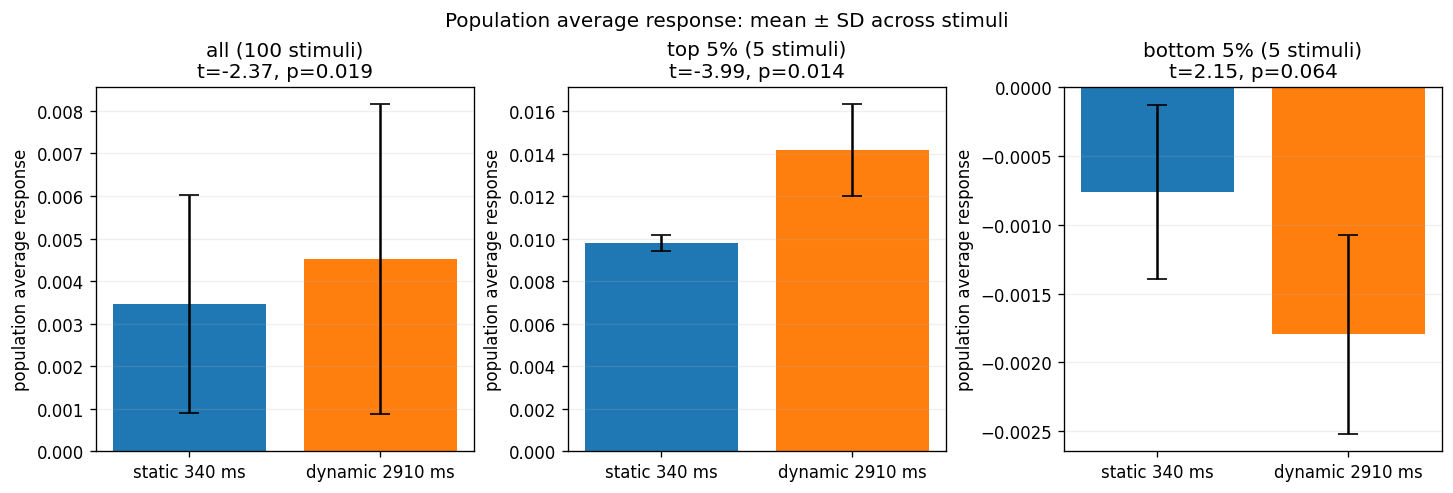

In [44]:
# One value per stimulus: mean across channels.
static_population = static_responses.mean(axis=0)
dynamic_population = dynamic_responses.mean(axis=0)
population_comparison = compare_static_dynamic_tails(
    static_population, dynamic_population, cfg.top_percent, cfg.bottom_percent,
)

figure, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
plot_static_dynamic_bars(
    axes, population_comparison, condition_labels,
    "population average response", "stimuli",
)
figure.suptitle("Population average response: mean ± SD across stimuli")
plt.show()

## 3. Single channels

The same comparison is run for every channel, ranking stimuli within each channel and condition. Each row shows one subset; bars are mean ± SD across stimuli. A star marks channels whose Welch p-value passes `cfg.channel_alpha` divided by the number of channels.

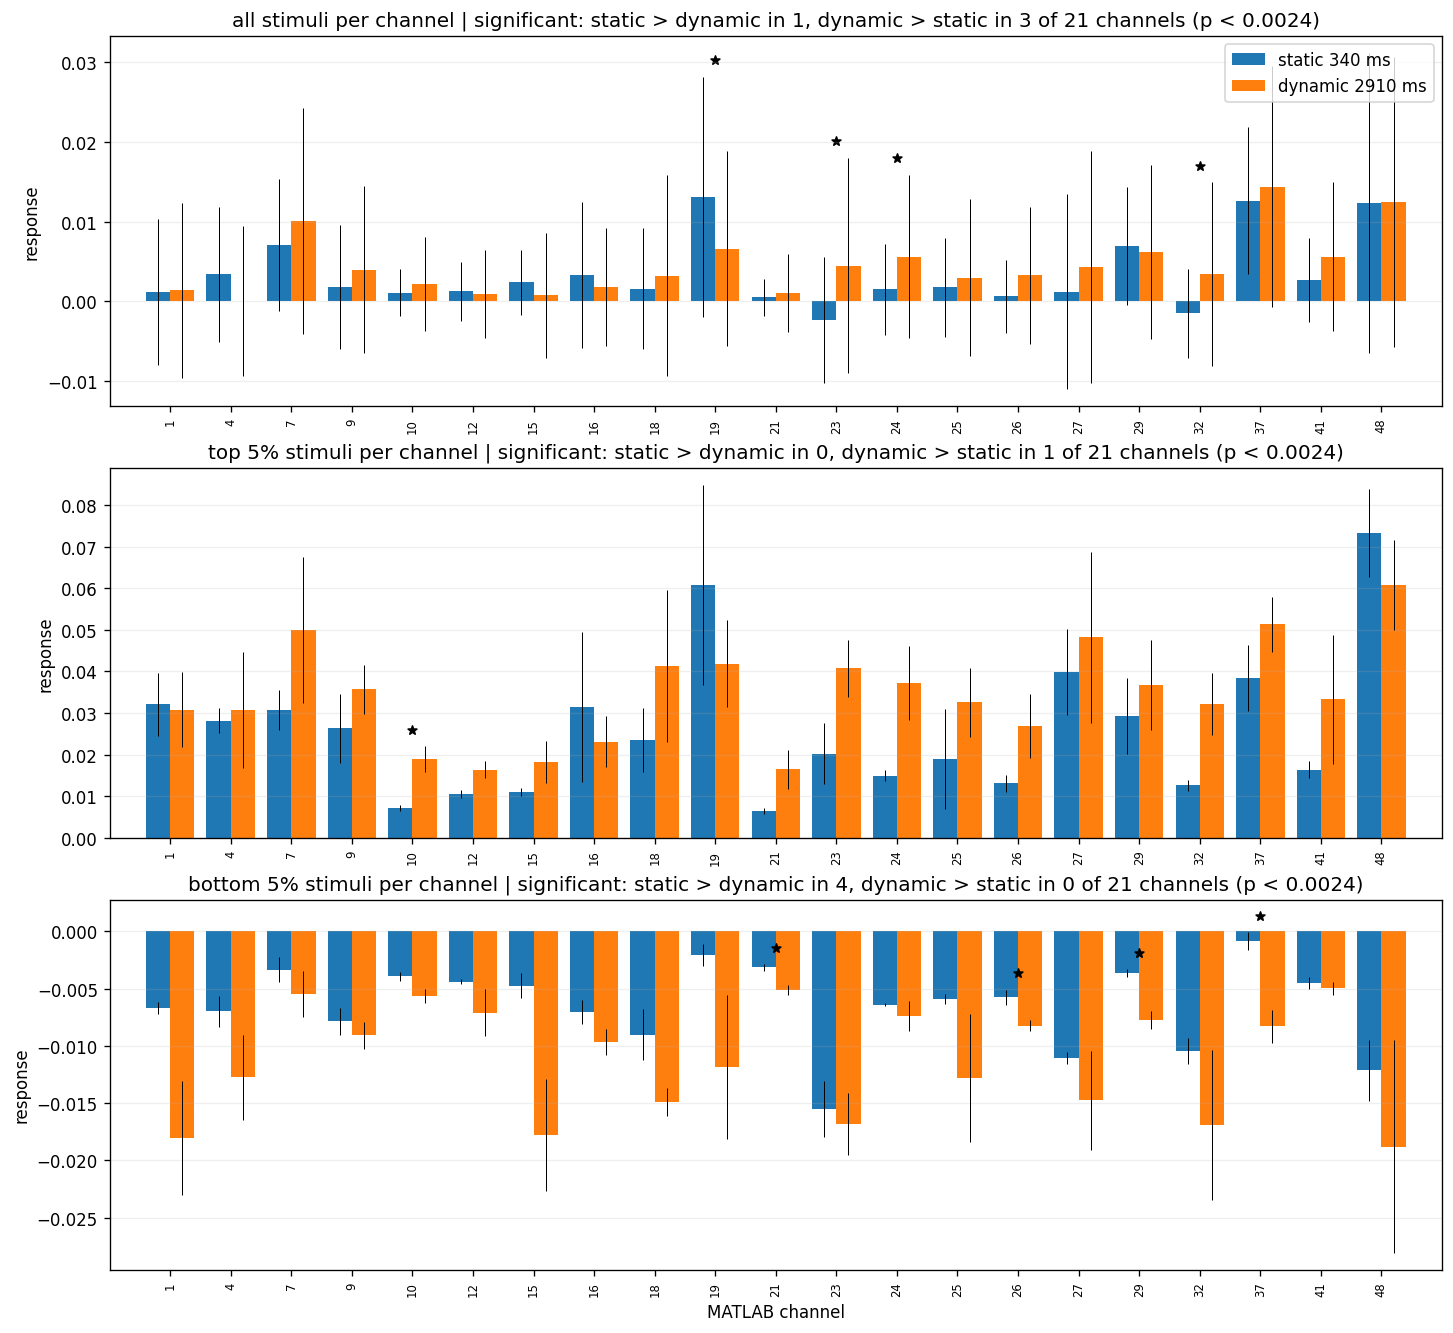

In [45]:
# Run the static-dynamic comparison separately for every channel.
channel_comparisons = [
    compare_static_dynamic_tails(
        static_responses[channel_index], dynamic_responses[channel_index],
        cfg.top_percent, cfg.bottom_percent,
    )
    for channel_index in range(static_responses.shape[0])
]
n_channels = len(channel_comparisons)
corrected_alpha = cfg.channel_alpha / n_channels
positions = np.arange(n_channels)
bar_width = 0.4

figure, axes = plt.subplots(
    3, 1, figsize=(max(12, 0.3 * n_channels), 11), constrained_layout=True,
)
for axis, subset in zip(axes, ("all", "top", "bottom")):
    # Stack per-channel summaries: rows are channels, columns static/dynamic.
    means = np.stack([comparison[subset]["mean"] for comparison in channel_comparisons])
    stds = np.stack([comparison[subset]["std"] for comparison in channel_comparisons])
    p_values = np.array([comparison[subset]["p"] for comparison in channel_comparisons])
    t_values = np.array([comparison[subset]["t"] for comparison in channel_comparisons])

    for column, (label, color, offset) in enumerate(zip(
            condition_labels, ("tab:blue", "tab:orange"), (-bar_width / 2, bar_width / 2),
            )):
        axis.bar(
            positions + offset, means[:, column], bar_width, yerr=stds[:, column],
            color=color, label=label, error_kw={"elinewidth": 0.6},
        )
    # end for column

    # Mark channels that survive the Bonferroni-corrected threshold.
    significant = p_values < corrected_alpha
    # Place stars a fixed margin above the error bars; responses can be negative.
    bar_tops = (means + stds).max(axis=1)
    star_margin = 0.05 * (bar_tops.max() - (means - stds).min())
    star_heights = bar_tops + star_margin
    axis.scatter(
        positions[significant], star_heights[significant],
        marker="*", color="black", s=30,
    )
    subset_label = channel_comparisons[0][subset]["label"]
    n_static_larger = int(np.sum(significant & (t_values > 0)))
    n_dynamic_larger = int(np.sum(significant & (t_values < 0)))
    axis.set(
        title=(
            f"{subset_label} stimuli per channel | significant: "
            f"static > dynamic in {n_static_larger}, dynamic > static in {n_dynamic_larger} "
            f"of {n_channels} channels (p < {corrected_alpha:.2g})"
        ),
        ylabel="response",
        xticks=positions,
        xlim=(-1, n_channels),
    )
    axis.set_xticklabels(channel_numbers, rotation=90, fontsize=7)
    axis.grid(alpha=0.2, axis="y")
# end for axis, subset
axes[0].legend()
axes[-1].set_xlabel("MATLAB channel")
plt.show()

## 4. Window-averaged RSA and pairwise distances

Instead of one timebin, each channel's response is averaged within `static_average_window_ms` and `dynamic_average_window_ms` (half-open, ms from onset, on the original `source_fs` rasters). One RDM per condition (`cfg.rdm_metric`) is built from these averages. The RSA is the Pearson and Spearman correlation between the static and dynamic RDMs across stimulus pairs; its p-values are optimistic because pairs are not independent. The barplots are the same as in section 1.


Window RSA (euclidean RDMs): Pearson r=0.023, p=1.04e-01; Spearman rho=0.032, p=2.36e-02


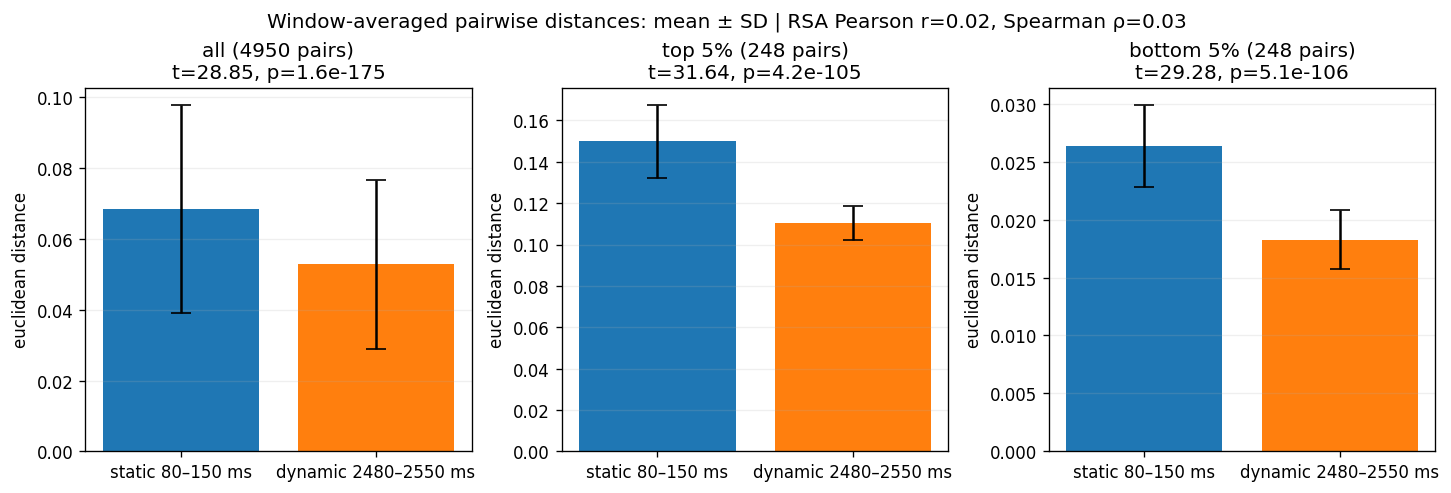

In [46]:
# Channels x stimuli, averaged within each condition's window.
static_window_responses, _ = window_mean_responses(
    static_rasters, cfg.static_average_window_ms, cfg.source_fs,
)
dynamic_window_responses, _ = window_mean_responses(
    dynamic_rasters, cfg.dynamic_average_window_ms, cfg.source_fs,
)
static_window_rdm = create_RDM(static_window_responses, cfg.rdm_metric)
dynamic_window_rdm = create_RDM(dynamic_window_responses, cfg.rdm_metric)

# RSA: similarity of the two geometries across stimulus pairs.
window_rsa_pearson = pearsonr(static_window_rdm, dynamic_window_rdm)
window_rsa_spearman = spearmanr(static_window_rdm, dynamic_window_rdm)
print(
    f"Window RSA ({cfg.rdm_metric} RDMs): "
    f"Pearson r={window_rsa_pearson.statistic:.3f}, "
    f"p={window_rsa_pearson.pvalue:.2e}; "
    f"Spearman rho={window_rsa_spearman.statistic:.3f}, "
    f"p={window_rsa_spearman.pvalue:.2e}"
)

window_distance_comparison = compare_static_dynamic_tails(
    static_window_rdm, dynamic_window_rdm,
    cfg.top_percent, cfg.bottom_percent,
)
window_condition_labels = (
    f"static {cfg.static_average_window_ms[0]:g}–"
    f"{cfg.static_average_window_ms[1]:g} ms",
    f"dynamic {cfg.dynamic_average_window_ms[0]:g}–"
    f"{cfg.dynamic_average_window_ms[1]:g} ms",
)

figure, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
plot_static_dynamic_bars(
    axes, window_distance_comparison, window_condition_labels,
    f"{cfg.rdm_metric} distance", "pairs",
)
figure.suptitle(
    "Window-averaged pairwise distances: mean ± SD | RSA "
    f"Pearson r={window_rsa_pearson.statistic:.2f}, "
    f"Spearman ρ={window_rsa_spearman.statistic:.2f}"
)
plt.show()


## 5. Distance magnitude and variance at every timepoint

One RDM (`cfg.rdm_metric`) is computed at every resampled timebin of each condition. Rows show all pairs, the top `cfg.top_percent`% and the bottom `cfg.bottom_percent`%, re-ranked at every timebin. Columns show the mean distance (static, dynamic) and the variance of the distances (static, dynamic). Static and dynamic panels of the same quantity share a y-axis. Dashed lines mark the timebins used in sections 1–3.


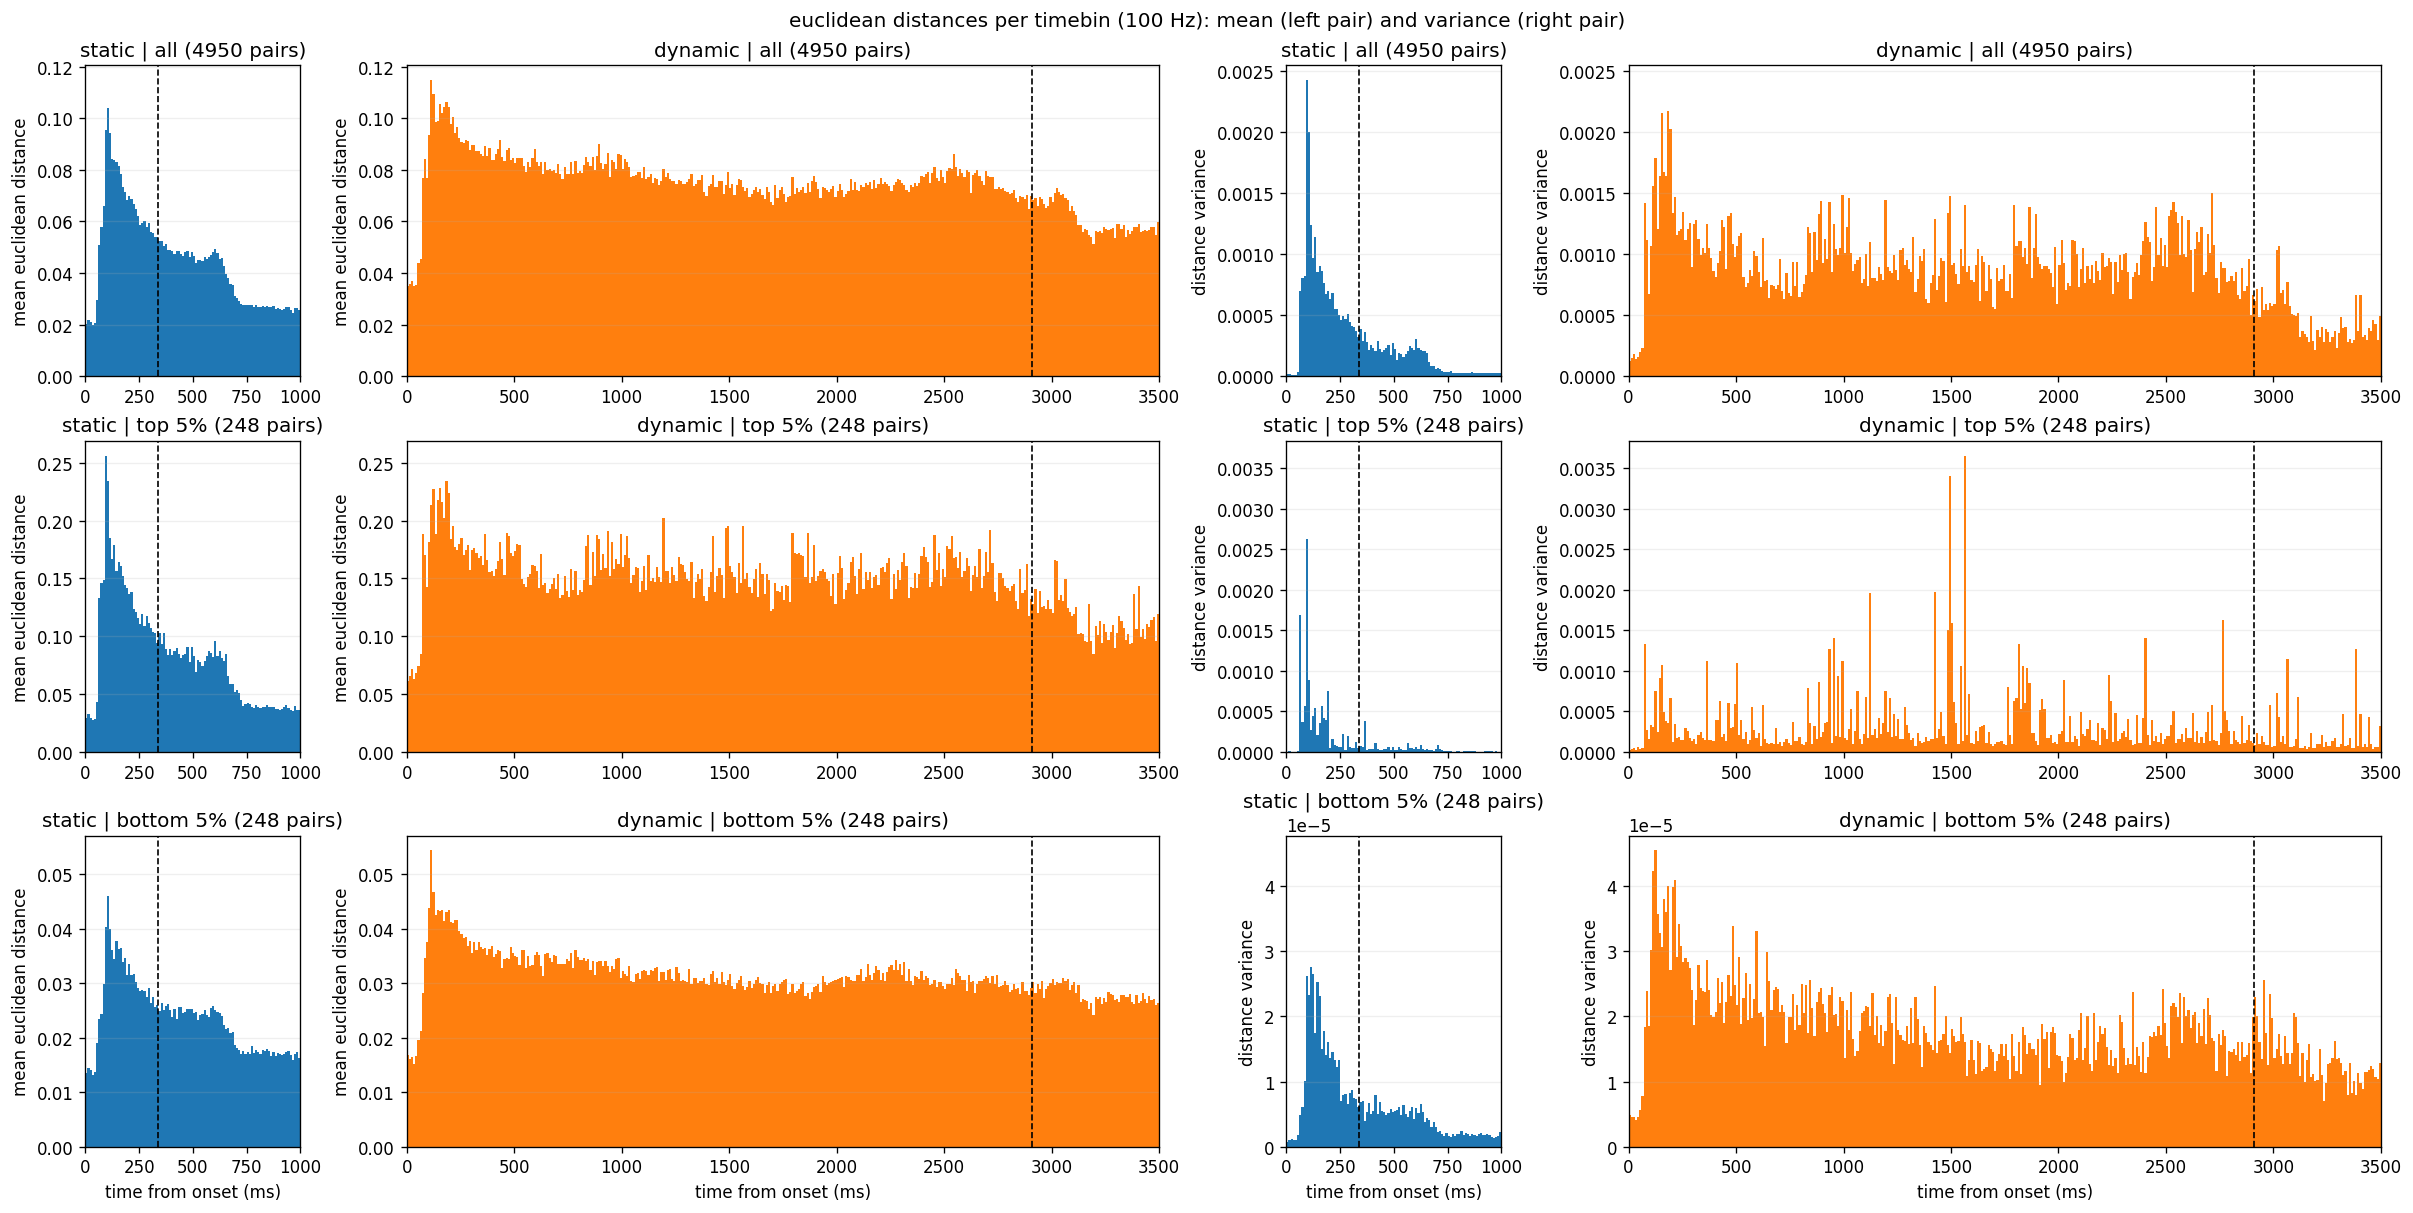

In [47]:
# RDM time series: time x stimulus pairs at new_fs.
static_rdm_timeseries = compute_rdm_timeseries(static.array, cfg.rdm_metric)
dynamic_rdm_timeseries = compute_rdm_timeseries(dynamic.array, cfg.rdm_metric)
static_tail_timecourses = rdm_tail_timecourses(
    static_rdm_timeseries, cfg.top_percent, cfg.bottom_percent,
)
dynamic_tail_timecourses = rdm_tail_timecourses(
    dynamic_rdm_timeseries, cfg.top_percent, cfg.bottom_percent,
)

# Bars start at each timebin onset, matching the index convention above.
bin_ms = 1000 / cfg.new_fs
static_bin_times_ms = np.arange(len(static_rdm_timeseries)) * bin_ms
dynamic_bin_times_ms = np.arange(len(dynamic_rdm_timeseries)) * bin_ms
column_specs = (
    ("mean", "static", static_tail_timecourses, static_bin_times_ms, static_time_ms, "tab:blue"),
    ("mean", "dynamic", dynamic_tail_timecourses, dynamic_bin_times_ms, dynamic_time_ms, "tab:orange"),
    ("var", "static", static_tail_timecourses, static_bin_times_ms, static_time_ms, "tab:blue"),
    ("var", "dynamic", dynamic_tail_timecourses, dynamic_bin_times_ms, dynamic_time_ms, "tab:orange"),
)

figure, axes = plt.subplots(
    3, 4, figsize=(20, 10), constrained_layout=True,
    gridspec_kw={"width_ratios": (1, 3.5, 1, 3.5)},
)
for row, subset in enumerate(("all", "top", "bottom")):
    for column, (statistic, condition, timecourses, times_ms, marked_ms, color) in enumerate(column_specs):
        axis = axes[row, column]
        summary = timecourses[subset]
        axis.bar(
            times_ms, summary[statistic], width=bin_ms, align="edge",
            color=color, linewidth=0,
        )
        axis.axvline(marked_ms, color="black", linestyle="--", linewidth=1)
        axis.set(
            title=f"{condition} | {summary['label']} ({summary['count']} pairs)",
            xlim=(times_ms[0], times_ms[-1] + bin_ms),
            ylabel=(
                f"mean {cfg.rdm_metric} distance" if statistic == "mean"
                else "distance variance"
            ),
        )
        axis.grid(alpha=0.2, axis="y")
    # end for column

    # Share y-limits between static and dynamic panels of the same statistic.
    for static_column in (0, 2):
        pair = axes[row, static_column:static_column + 2]
        y_max = max(axis.get_ylim()[1] for axis in pair)
        for axis in pair:
            axis.set_ylim(0, y_max)
        # end for axis
    # end for static_column
# end for row
for axis in axes[-1]:
    axis.set_xlabel("time from onset (ms)")
# end for axis
figure.suptitle(
    f"{cfg.rdm_metric} distances per timebin ({cfg.new_fs:g} Hz): "
    "mean (left pair) and variance (right pair)"
)
plt.show()


## 6. Cross-temporal comparison of distance magnitudes

For every pair of timebins (static time, dynamic time), the static RDM distances are compared with the dynamic RDM distances by Welch's t-test. This is done for all pairs and for each RDM's own top `cfg.top_percent`% (largest distances) and bottom `cfg.bottom_percent`% (smallest distances). Matrices use the dRSA layout (movie time on x, static time on y). Welch t is static − dynamic: red means larger static distances, blue larger dynamic distances, white no difference; the colour scale is symmetric around zero within each matrix. As in section 1, pairs are not independent, so t values are inflated.


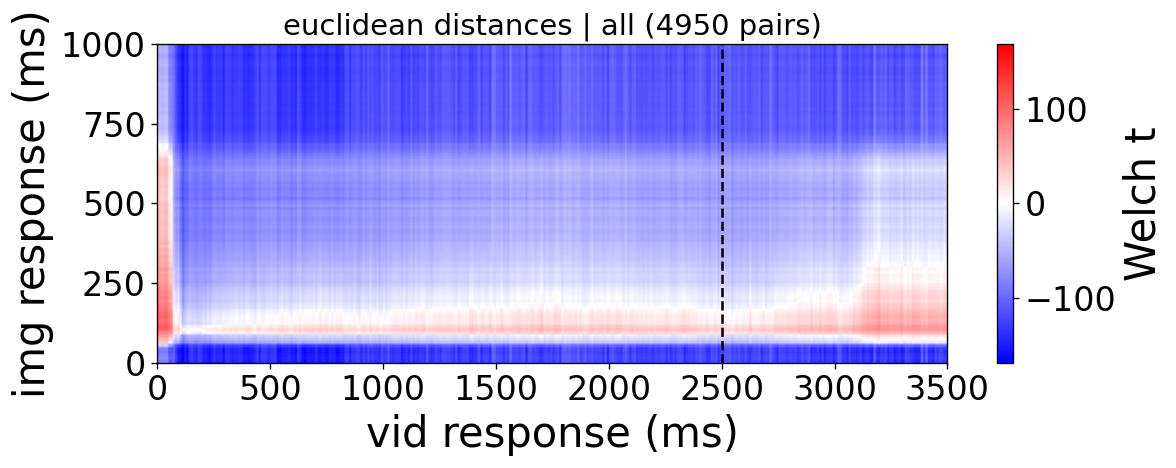

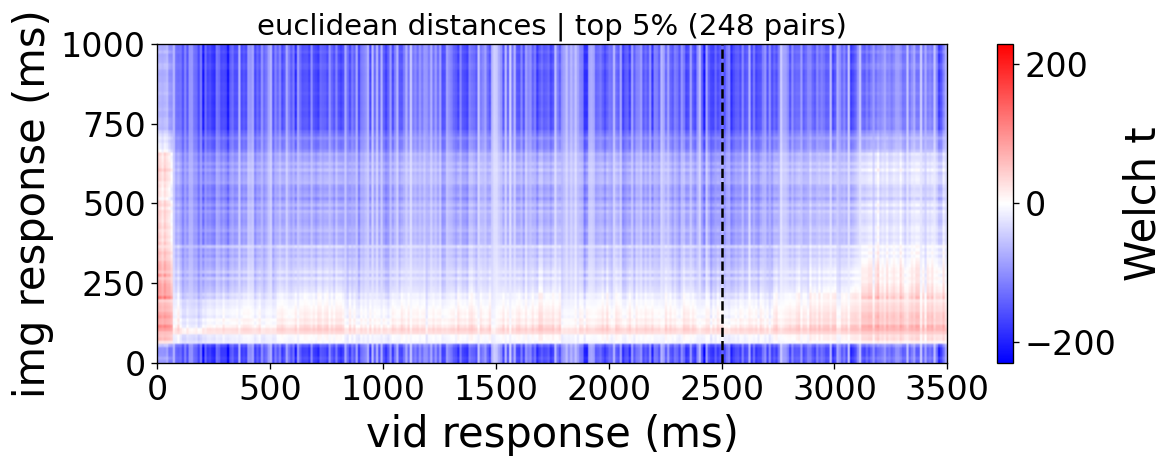

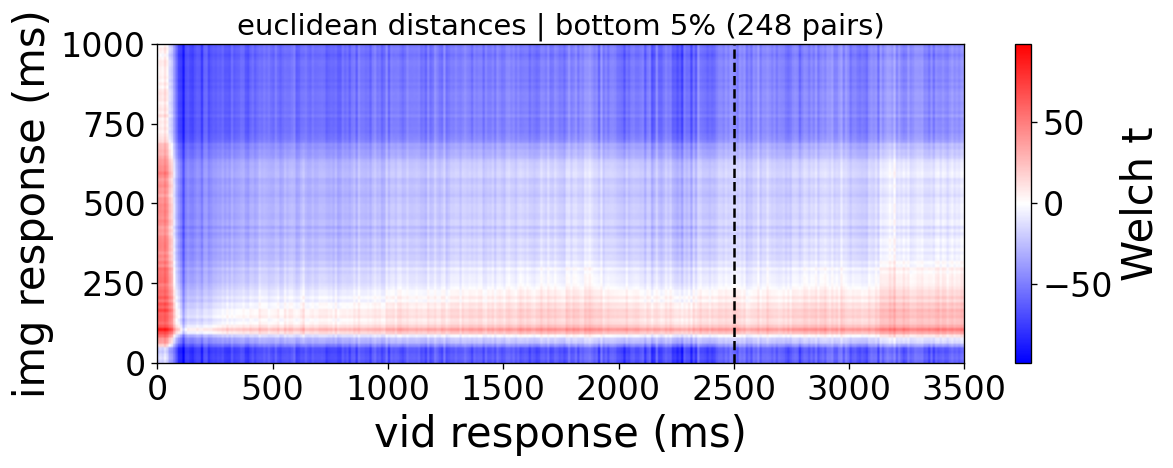

In [48]:
# Dynamic time x static time Welch t values, reusing section 5's RDM time series.
tail_t_matrices = cross_temporal_tail_ttest(
    static_rdm_timeseries, dynamic_rdm_timeseries,
    cfg.top_percent, cfg.bottom_percent,
)
for subset, summary in tail_t_matrices.items():
    # Symmetric limits put white exactly at t = 0.
    t_limit = np.nanmax(np.abs(summary["t"]))
    figure, axis = plt.subplots(figsize=cfg.matrix_figsize)
    plot_static_dynamic_matrix(
        axis, summary["t"], 1000 / cfg.new_fs,
        cmap="bwr", vmin=-t_limit, vmax=t_limit,
        colorbar_label="Welch t",
        last_frame_onset_ms=cfg.last_frame_onset_ms,
        last_frame_color="black",
        ticks_size=cfg.ticks_size,
        label_size=cfg.label_size,
    )
    axis.set_title(
        f"{cfg.rdm_metric} distances | {summary['label']} "
        f"({summary['count']} pairs)",
        fontsize=cfg.label_size * 0.7,
    )
    figure.tight_layout()
    plt.show()
# end for subset


## 7. RDM distance scatterplots at chosen timepoints

Edit `scatter_timepoints` at the top of the cell: three `(static_time_ms, dynamic_time_ms)` pairs, one per panel. Either entry can be `"drsa_peak"` to use that condition's timebin at the static-dynamic dRSA peak (computed with the `drsa_*` settings if section 1 used fixed times). Each point is one stimulus pair; distances come from the section-5 RDMs (`cfg.rdm_metric`, `cfg.new_fs`), so times are rounded to the nearest timebin onset.

Rows show all pairs, the top `scatter_top_percent`% and the bottom `scatter_bottom_percent`% (set at the top of the cell). As elsewhere in this notebook, each condition's tail is ranked on its own, so the two tails can contain different pairs. Tail panels therefore show the union of both tails, coloured by membership: static tail only (blue), dynamic tail only (orange), or both (purple). Each title reports the static and dynamic means and Welch's t-test comparing each condition's own selection — the same test as sections 1 and 4. Pairs are not independent, so p-values are optimistic.


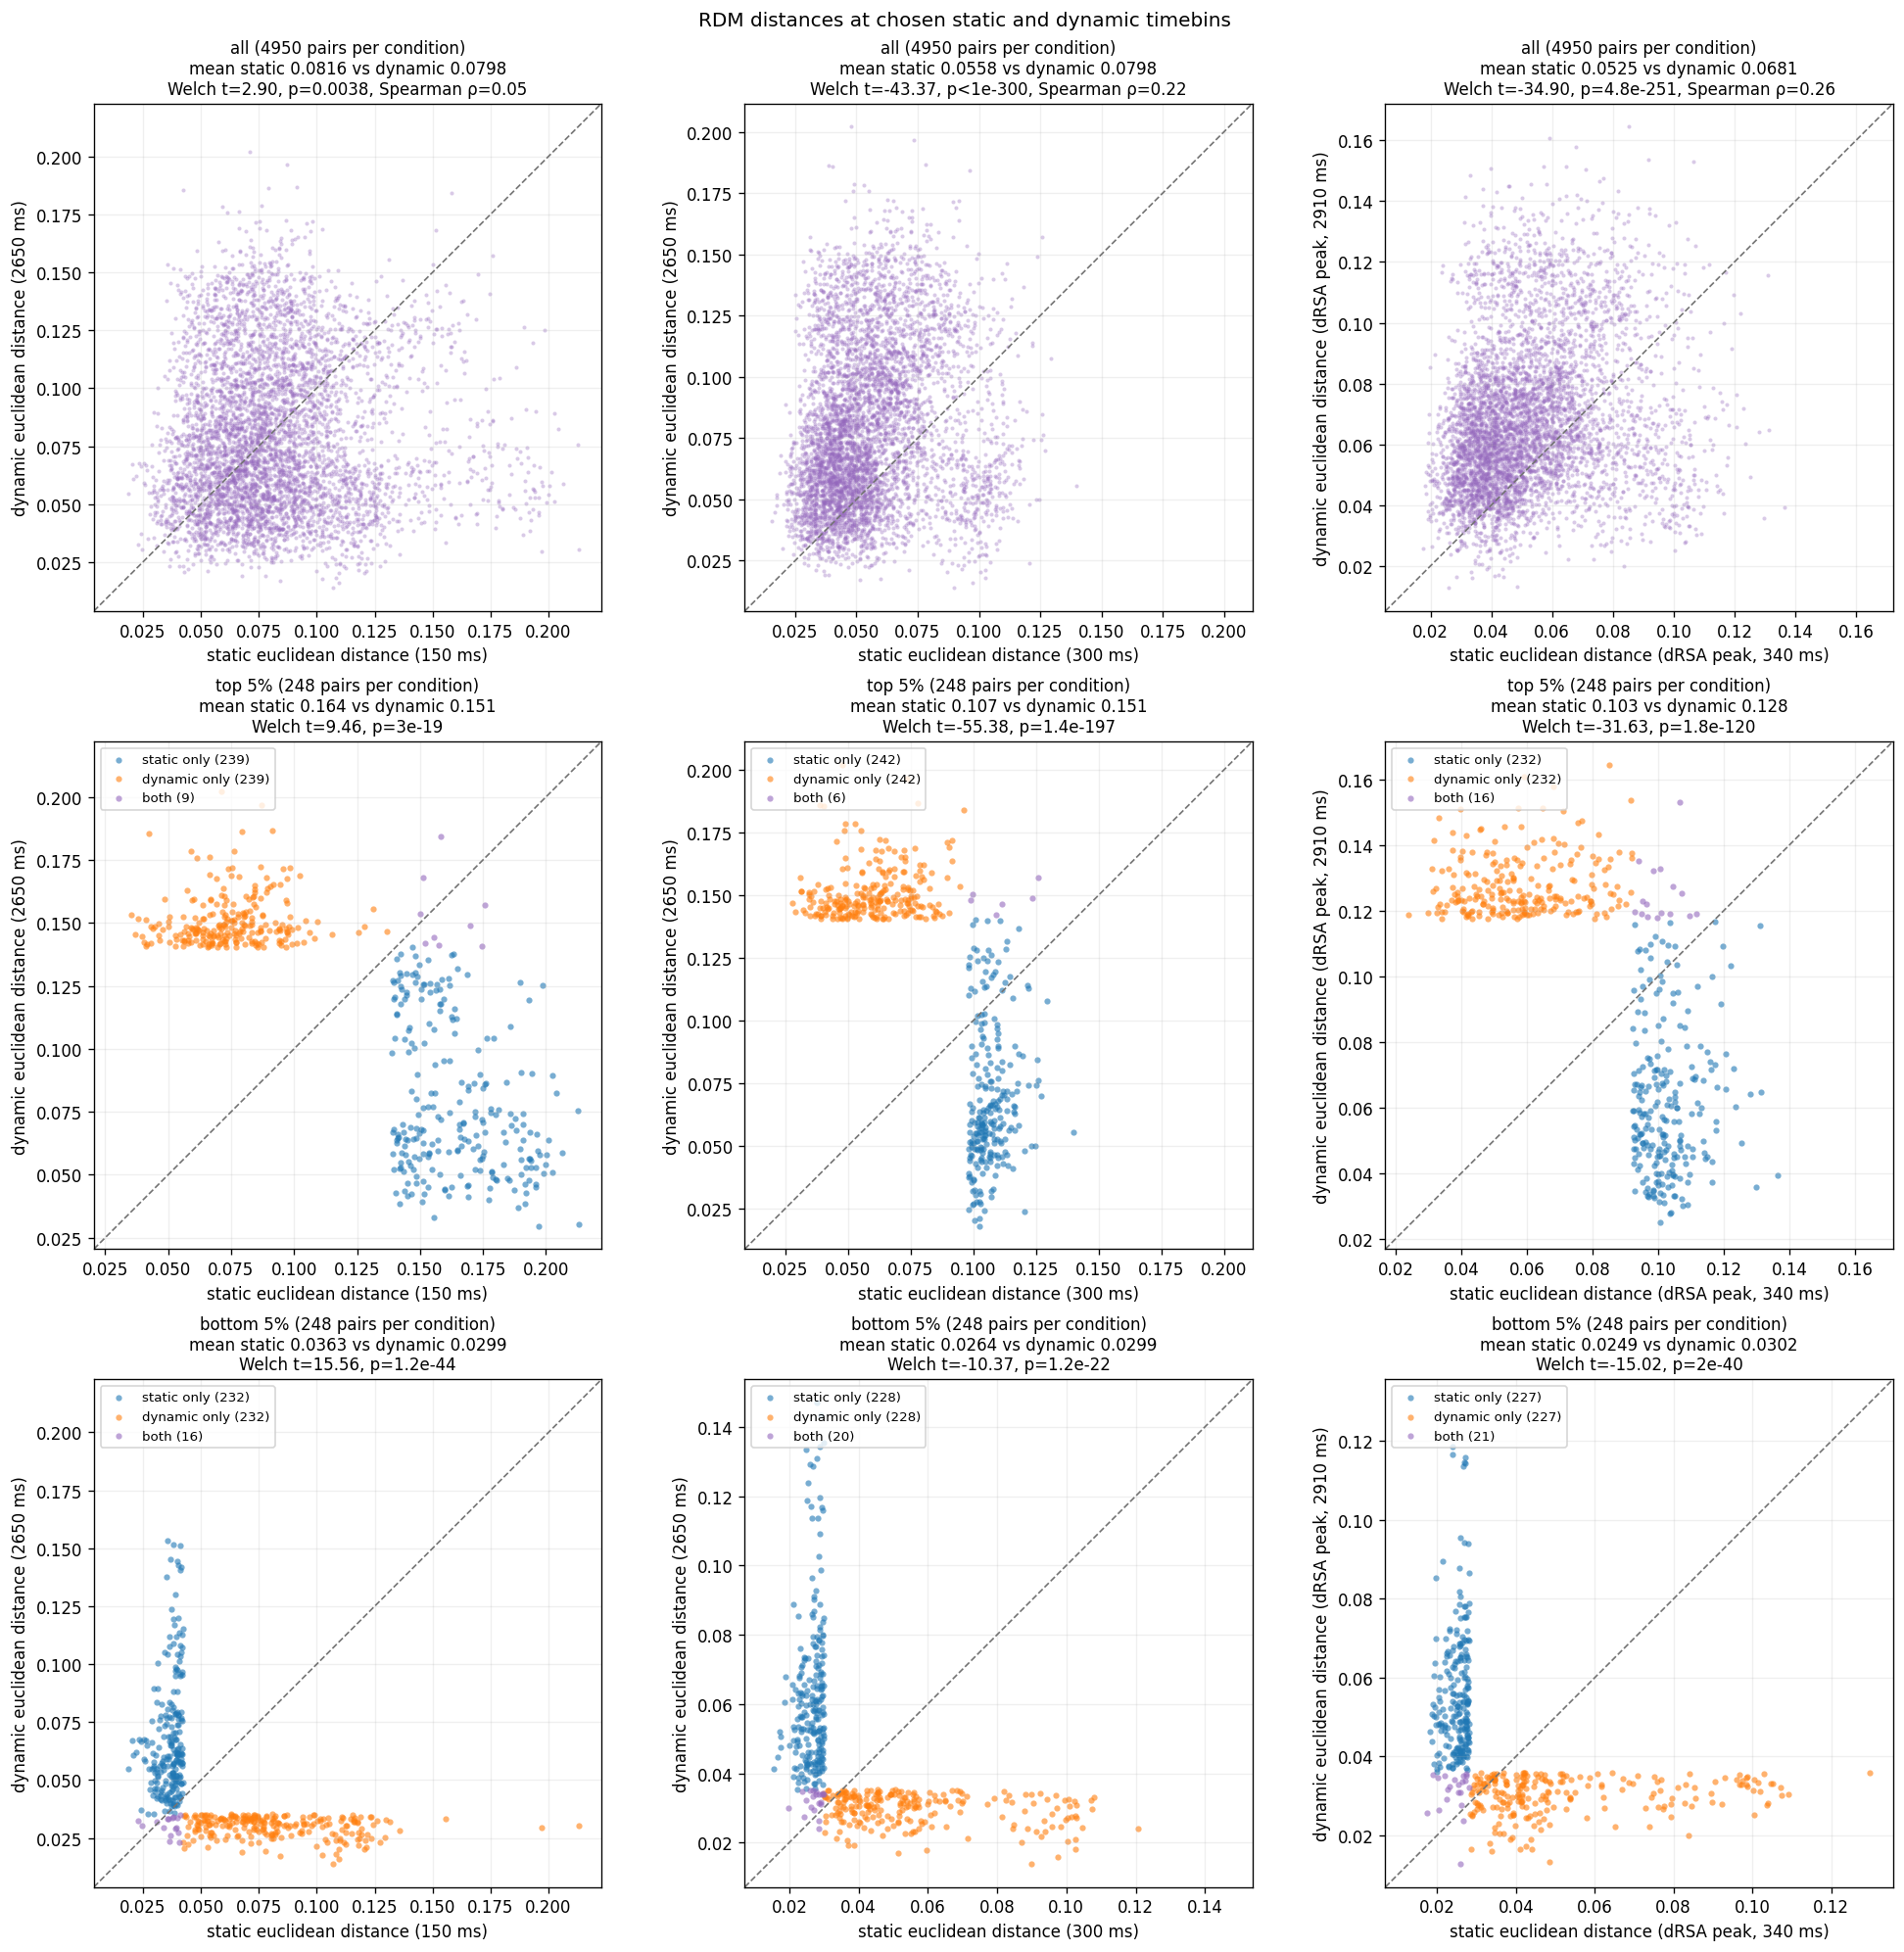

In [49]:
# One (static_time_ms, dynamic_time_ms) pair per panel; "drsa_peak" selects
# that condition's timebin at the static-dynamic dRSA peak.
scatter_timepoints = (
    (150, 2650),
    (300, 2650),
    ("drsa_peak", "drsa_peak"),
)
# Tails used in the second and third rows.
scatter_top_percent = cfg.top_percent
scatter_bottom_percent = cfg.bottom_percent

# Compute the dRSA peak only if a panel needs it and section 1 did not.
needs_drsa_peak = any("drsa_peak" in pair for pair in scatter_timepoints)
if needs_drsa_peak and cfg.timepoint_source != "drsa_peak":
    previous_static_array = None
    if cfg.drsa_previous_static_response is not None:
        previous_static = TimeSeries(
            static_rasters_by_response[cfg.drsa_previous_static_response],
            cfg.source_fs,
        )
        previous_static.resample(cfg.new_fs)
        previous_static_array = previous_static.array
    # end if previous frame requested
    drsa_peak = static_dynamic_drsa_peak(
        static.array, dynamic.array,
        source_fs=cfg.new_fs,
        drsa_fs=cfg.new_fs,
        static_search_ms=cfg.drsa_static_search_ms,
        dynamic_search_ms=cfg.drsa_dynamic_search_ms,
        half_window_ms=0,
        rdm_metric=cfg.rdm_metric,
        rsa_metric=cfg.drsa_rsa_metric,
        smoothing_sigma_bins=cfg.drsa_smoothing_sigma_bins,
        previous_static_rasters=previous_static_array,
        previous_regression=cfg.drsa_previous_regression,
    )
# end if dRSA peak needed


"""
resolve_time_index
Converts a requested time (or "drsa_peak") into an RDM timebin index.
Script-specific: it relies on this notebook's drsa_peak and new_fs.

INPUT:
    - requested_time: float | str -> time in ms from onset, or "drsa_peak"
    - condition: str -> "static" or "dynamic"
    - n_bins: int -> number of timebins in that condition's RDM time series

OUTPUT:
    - time_index: int -> timebin index in the RDM time series
"""
def resolve_time_index(requested_time, condition, n_bins):
    if requested_time == "drsa_peak":
        time_index = drsa_peak[f"peak_{condition}_index"]
    else:
        time_index = int(round(requested_time * cfg.new_fs / 1000))
    # end if drsa_peak
    if not 0 <= time_index < n_bins:
        raise ValueError(f"{condition} time {requested_time!r} is outside the response.")
    # end if outside the response
    return time_index
# EOF


subset_percents = {
    "all": 100, "top": scatter_top_percent, "bottom": scatter_bottom_percent,
}
membership_colors = {
    "static only": "tab:blue", "dynamic only": "tab:orange", "both": "tab:purple",
}
figure, axes = plt.subplots(
    len(subset_percents), len(scatter_timepoints),
    figsize=(5.5 * len(scatter_timepoints), 5.5 * len(subset_percents)),
    constrained_layout=True, squeeze=False,
)
for column, (static_request, dynamic_request) in enumerate(scatter_timepoints):
    static_scatter_index = resolve_time_index(
        static_request, "static", len(static_rdm_timeseries),
    )
    dynamic_scatter_index = resolve_time_index(
        dynamic_request, "dynamic", len(dynamic_rdm_timeseries),
    )
    # One distance per stimulus pair in each condition.
    static_distances = static_rdm_timeseries[static_scatter_index]
    dynamic_distances = dynamic_rdm_timeseries[dynamic_scatter_index]
    static_label = "dRSA peak, " if static_request == "drsa_peak" else ""
    dynamic_label = "dRSA peak, " if dynamic_request == "drsa_peak" else ""
    # Welch tests on each condition's own ranking, as in sections 1 and 4.
    magnitude_comparison = compare_static_dynamic_tails(
        static_distances, dynamic_distances,
        scatter_top_percent, scatter_bottom_percent,
    )

    for row, (subset, percent) in enumerate(subset_percents.items()):
        axis = axes[row, column]
        # Pair indices in each condition's own tail.
        static_tail = select_tail_indices(static_distances, subset, percent)
        dynamic_tail = select_tail_indices(dynamic_distances, subset, percent)
        in_static = np.zeros(static_distances.size, dtype=bool)
        in_static[static_tail] = True
        in_dynamic = np.zeros(dynamic_distances.size, dtype=bool)
        in_dynamic[dynamic_tail] = True
        memberships = {
            "static only": in_static & ~in_dynamic,
            "dynamic only": in_dynamic & ~in_static,
            "both": in_static & in_dynamic,
        }

        for membership, mask in memberships.items():
            if not mask.any():
                continue
            # end if no pairs in this group
            axis.scatter(
                static_distances[mask], dynamic_distances[mask],
                s=6 if subset == "all" else 14, alpha=0.35 if subset == "all" else 0.6,
                color=membership_colors[membership], linewidth=0,
                label=None if subset == "all" else f"{membership} ({mask.sum()})",
            )
        # end for membership

        # Equal limits around the shown pairs so the identity line is meaningful.
        shown = in_static | in_dynamic
        shown_values = np.concatenate([static_distances[shown], dynamic_distances[shown]])
        padding = 0.05 * max(np.ptp(shown_values), 1e-12)
        limits = (shown_values.min() - padding, shown_values.max() + padding)
        axis.plot(limits, limits, "--", color="0.45", linewidth=1)

        summary = magnitude_comparison[subset]
        # Very small p-values underflow to exactly 0 in float64.
        p_text = "<1e-300" if summary["p"] == 0 else f"={summary['p']:.2g}"
        title = (
            f"{summary['label']} ({summary['count']} pairs per condition)\n"
            f"mean static {summary['mean'][0]:.3g} vs dynamic {summary['mean'][1]:.3g}\n"
            f"Welch t={summary['t']:.2f}, p{p_text}"
        )
        if subset == "all":
            spearman_result = spearmanr(static_distances, dynamic_distances)
            title += f", Spearman ρ={spearman_result.statistic:.2f}"
        else:
            axis.legend(fontsize=8, loc="upper left")
        # end if subset == "all"
        axis.set(
            xlim=limits, ylim=limits, aspect="equal", title=title,
            xlabel=(
                f"static {cfg.rdm_metric} distance "
                f"({static_label}{static_scatter_index * 1000 / cfg.new_fs:g} ms)"
            ),
            ylabel=(
                f"dynamic {cfg.rdm_metric} distance "
                f"({dynamic_label}{dynamic_scatter_index * 1000 / cfg.new_fs:g} ms)"
            ),
        )
        axis.title.set_fontsize(10)
        axis.grid(alpha=0.2)
    # end for row
# end for column
figure.suptitle("RDM distances at chosen static and dynamic timebins")
plt.show()
